# Non-Informative Priors in Bayesian Statistics



In [13]:
import numpy as np
from scipy.stats import multinomial, norm
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

In [10]:
class RiemannianManifold(ABC):
    def __init__(self, bounds, dim, vf_bound):
        self.bounds = bounds
        self.dim = dim
        self.vf_bound = vf_bound

    @abstractmethod
    def coords(self, u):
        pass

    def metric(self, u):
        pass

    def volume_form(self, u):
        return np.sqrt(np.linalg.det(self.metric(u)))

    def _param_samples(self, n_samples, M):
        samples = []
        lows, highs = zip(*self.bounds)

        while len(samples) < n_samples:
            x = np.random.uniform(lows, highs, size=(self.dim,))
            u = np.random.uniform()
            if u * M <= self.volume_form(x):
                samples.append(x)

        return samples

    def sample(self, n_samples):
        param_samples = self._param_samples(n_samples, self.vf_bound)
        return [self.coords(x) for x in param_samples]

## Normal Family

In [14]:
class NormalFamily(RiemannianManifold):
    def __init__(self, mu_bounds, sigma2_bounds, n_samples=1):
        a, b = sigma2_bounds
        vf_bound = n_samples / (np.sqrt(2.0) * (a ** 1.5))
        super().__init__(bounds=[mu_bounds, sigma2_bounds], dim=2, vf_bound=vf_bound)
        self.n_samples = n_samples

    def coords(self, u):
        mu, sigma2 = u
        return norm(loc=float(mu), scale=np.sqrt(float(sigma2)))

    def metric(self, u):
        _, sigma2 = u
        return self.n_samples * np.array([
            [1.0 / sigma2, 0.0],
            [0.0, 1.0 / (2.0 * sigma2 ** 2)],
        ])

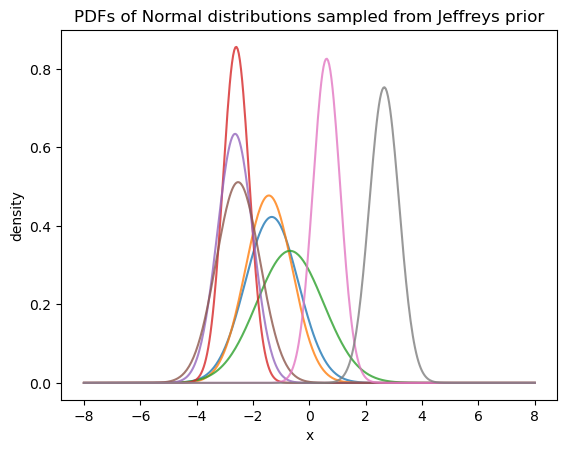

In [15]:
normal_family = NormalFamily(mu_bounds=(-3.0, 3.0), sigma2_bounds=(0.2, 2.0), n_samples=2)
sampled_normals = normal_family.sample(8)

x = np.linspace(-8.0, 8.0, 400)
for d in sampled_normals:
    plt.plot(x, d.pdf(x), alpha=0.8)

plt.title("PDFs of Normal distributions sampled from Jeffreys prior")
plt.xlabel("x")
plt.ylabel("density")
plt.show()

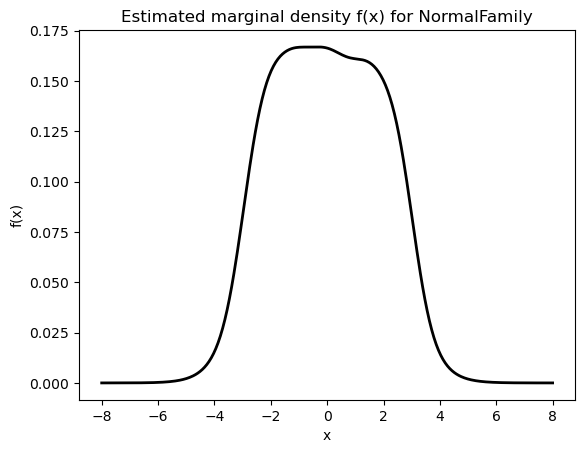

In [17]:
def marginal_normal_grid(x_grid, family, n_samples=5000):
    dists = family.sample(n_samples)
    return np.mean([d.pdf(x_grid) for d in dists], axis=0)

x_grid = np.linspace(-8.0, 8.0, 400)
f_grid = marginal_normal_grid(x_grid, normal_family, n_samples=5000)

plt.plot(x_grid, f_grid, color="black", linewidth=2)
plt.title("Estimated marginal density f(x) for NormalFamily")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()